# Milestone 1

# Part 1: Data Cleaning

> **Data source:** Download the MoMA dataset from [Kaggle]([https://www.kaggle.com/datasets/mfrancis23/museum-of-modern-art-collection](https://www.kaggle.com/datasets/mfrancis23/museum-of-modern-art-collection)) and place `Artworks.csv` and `Artists.csv` into the `data/raw/` folder before running this notebook.

This notebook performs the following data cleaning steps:

1. **Load** the raw `Artworks.csv`
2. **Clean Artworks** – remove duplicate titles, drop rows containing "Unknown", extract the first four-digit year from `Date`, load `Artists.csv` to look up Artist name and Gender by `ConstituentID`
3. **Clean Artists** – remove artists with invalid `BeginDate`, missing `Nationality`, or missing `Gender`, then drop their corresponding artworks
4. **Select columns & export** – trim both DataFrames to essential columns and save as UTF-8 BOM CSV

## 1.1 Load the Data

In [1]:
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

# Load raw Artworks dataset
df = pd.read_csv("../../data/raw/Artworks.csv")
print(f"Original shape: {df.shape}")
df.head()

Original shape: (138161, 29)


,Title,Artist,ConstituentID,ArtistBio,Nationality,BeginDate,EndDate,Gender,Date,Medium,...,ThumbnailURL,Circumference (cm),Depth (cm),Diameter (cm),Height (cm),Length (cm),Weight (kg),Width (cm),Seat Height (cm),Duration (sec.)
0,"Ferdinandsbrücke Project, Vienna, Austria (Ele...",Otto Wagner,6210,"(Austrian, 1841–1918)",(Austrian),(1841),(1918),(Male),1896,Ink and cut-and-pasted painted pages on paper,...,http://www.moma.org/media/W1siZiIsIjU5NDA1Il0s...,NaN,NaN,NaN,48.6000,NaN,NaN,168.9000,NaN,NaN
1,"City of Music, National Superior Conservatory ...",Christian de Portzamparc,7470,"(French, born 1944)",(French),(1944),(0),(Male),1987,Paint and colored pencil on print,...,http://www.moma.org/media/W1siZiIsIjk3Il0sWyJw...,NaN,NaN,NaN,40.6401,NaN,NaN,29.8451,NaN,NaN
2,"Villa near Vienna Project, Outside Vienna, Aus...",Emil Hoppe,7605,"(Austrian, 1876–1957)",(Austrian),(1876),(1957),(Male),1903,"Graphite, pen, color pencil, ink, and gouache ...",...,http://www.moma.org/media/W1siZiIsIjk4Il0sWyJw...,NaN,NaN,NaN,34.3000,NaN,NaN,31.8000,NaN,NaN
3,"The Manhattan Transcripts Project, New York, N...",Bernard Tschumi,7056,"(French and Swiss, born Switzerland 1944)",(),(1944),(0),(Male),1980,Photographic reproduction with colored synthet...,...,http://www.moma.org/media/W1siZiIsIjEyNCJdLFsi...,NaN,NaN,NaN,50.8000,NaN,NaN,50.8000,NaN,NaN
4,"Villa, project, outside Vienna, Austria, Exter...",Emil Hoppe,7605,"(Austrian, 1876–1957)",(Austrian),(1876),(1957),(Male),1903,"Graphite, color pencil, ink, and gouache on tr...",...,http://www.moma.org/media/W1siZiIsIjEyNiJdLFsi...,NaN,NaN,NaN,38.4000,NaN,NaN,19.1000,NaN,NaN


## 1.2 Clean the Artworks Data

### 1.2.1 Remove Duplicate Titles

Use the portion of `Title` before the first comma as the dedup key, keeping only the first occurrence.

In [2]:
before = len(df)

# Alternative: dedup by the entire Title
# df = df.drop_duplicates(subset="Title", keep="first")

# Use the part before the first comma as the dedup key
df["_title_key"] = df["Title"].str.split(",").str[0]

df = df.drop_duplicates(subset="_title_key", keep="first")
df = df.drop(columns=["_title_key"])
print(f"Removed {before - len(df)} duplicate-title rows. Remaining: {len(df)}")

Removed 47838 duplicate-title rows. Remaining: 90323


### 1.2.2 Remove Rows Containing "Unknown"

Drop any row where **any** column contains the word "Unknown" (case-insensitive).

In [3]:
before = len(df)
# Check all string columns for the word "unknown" (case-insensitive)
mask = df.apply(lambda row: row.astype(str).str.contains("unknown", case=False).any(), axis=1)
df = df[~mask]
print(f"Removed {before - len(df)} rows containing 'Unknown'. Remaining: {len(df)}")

Removed 2314 rows containing 'Unknown'. Remaining: 88009


### 1.2.3 Clean the Date Column

Extract the **first four-digit year** from the `Date` column using a regex pattern. Rows where no valid year can be extracted are dropped.

In [4]:
# Extract the first 4-digit year from the Date column
df["Date"] = df["Date"].astype(str).str.extract(r"(\d{4})", expand=False)

# Drop rows where no valid year was found
before = len(df)
df = df.dropna(subset=["Date"])
print(f"Dropped {before - len(df)} rows with no valid year. Remaining: {len(df)}")
print("\nSample cleaned Date values:")
print(df["Date"].value_counts().head(10))

Dropped 1632 rows with no valid year. Remaining: 86377

Sample cleaned Date values:
Date
1965    1641
1966    1633
1968    1620
1967    1586
1969    1509
1930    1442
1964    1399
1991    1238
1962    1222
1970    1170
Name: count, dtype: int64


### 1.2.4 Clean Artist Column

1. Load `Artists.csv` to build a ConstituentID → DisplayName/Gender mapping  
2. Remove rows where `Artist` is empty  
3. Split by `ConstituentID` (comma-separated), look up Artist name and Gender from Artists table  
4. Report remaining rows with any empty values

In [5]:
# Load Artists dataset for ID → Name/Gender/Nationality lookup
df_artists = pd.read_csv("../../data/raw/Artists.csv")
print(f"Loaded Artists: {df_artists.shape}")

# Build lookup maps: ConstituentID → DisplayName / Gender / Nationality
id_to_name = df_artists.set_index("ConstituentID")["DisplayName"].to_dict()
id_to_gender = df_artists.set_index("ConstituentID")["Gender"].to_dict()
id_to_nationality = df_artists.set_index("ConstituentID")["Nationality"].to_dict()

# Remove rows where Artist is empty
before = len(df)
df = df.dropna(subset=["Artist"])
df = df[df["Artist"].str.strip() != ""]
print(f"Removed {before - len(df)} rows with empty Artist. Remaining: {len(df)}")

# Split by ConstituentID (reliable comma-separated), then look up Artist name, Gender, Nationality
before = len(df)
df["ConstituentID"] = df["ConstituentID"].astype(str).str.split(",")
df = df.explode("ConstituentID").reset_index(drop=True)
df["ConstituentID"] = df["ConstituentID"].str.strip()

# Look up Artist name, Gender, and Nationality from Artists table
df["Artist"] = df["ConstituentID"].apply(lambda x: id_to_name.get(int(x), "") if x.isdigit() else "")
df["Gender"] = df["ConstituentID"].apply(lambda x: id_to_gender.get(int(x), "") if x.isdigit() else "")
df["Nationality"] = df["ConstituentID"].apply(lambda x: id_to_nationality.get(int(x), "") if x.isdigit() else "")

# Remove rows where lookup failed (empty Artist)
df = df[df["Artist"].str.strip() != ""].reset_index(drop=True)
print(f"Expanded multi-artist rows: {len(df) - before} new rows added. Total: {len(df)}")

# Check remaining rows with any empty/NaN values (only in columns we will keep)
check_cols = ["Title", "Artist", "ConstituentID", "Nationality", "Gender", "Date",
              "Classification", "Department", "ObjectID", "URL", "ThumbnailURL"]
check_cols = [c for c in check_cols if c in df.columns]
empty_mask = df[check_cols].isnull().any(axis=1) | df[check_cols].apply(
    lambda row: (row.astype(str).str.strip() == "").any(), axis=1
)
rows_with_empty = df[empty_mask]
if len(rows_with_empty) > 0:
    print(f"\nFound {len(rows_with_empty)} rows with empty values.")
else:
    print("\nNo remaining rows with empty values.")

# Delete rows with any empty values
# df = df[~empty_mask].reset_index(drop=True)
# print(f"After removing rows with empty values: {len(df)}")

Loaded Artists: (15282, 9)
Removed 513 rows with empty Artist. Remaining: 85864
Expanded multi-artist rows: 7890 new rows added. Total: 93754

Found 45439 rows with empty values.


## 1.3 Clean Artists Data

Remove artists with invalid `BeginDate`, missing `Nationality`, or missing `Gender` from the already-loaded `df_artists`, then drop their corresponding artworks.

In [6]:
# Identify invalid artists:
#   - BeginDate is 0 or missing
#   - Nationality is missing or "Nationality unknown"
#   - Gender is missing
invalid_mask = (
    df_artists["BeginDate"].isna() | (df_artists["BeginDate"] == 0)
    | df_artists["Nationality"].isna() | (df_artists["Nationality"].str.strip() == "")
    | (df_artists["Nationality"].str.lower() == "nationality unknown")
    | df_artists["Gender"].isna() | (df_artists["Gender"].str.strip() == "")
)
invalid_artists = df_artists[invalid_mask]
print(f"Invalid artists (BeginDate/Nationality/Gender issues): {len(invalid_artists)}")

# Remove these artists from the Artists DataFrame
df_artists = df_artists[~invalid_mask]
print(f"Artists after cleaning: {len(df_artists)}")

# Standardize Gender values: "male" -> "Male", "female" -> "Female"
df_artists["Gender"] = df_artists["Gender"].replace({"male": "Male", "female": "Female"})
df["Gender"] = df["Gender"].replace({"male": "Male", "female": "Female"})

# Get the ConstituentIDs of invalid artists
invalid_ids = set(invalid_artists["ConstituentID"].astype(str))

# Drop artworks by invalid artists (ConstituentID is already single-value after step 5 explode)
before = len(df)
df = df[~df["ConstituentID"].astype(str).isin(invalid_ids)]
print(f"Dropped {before - len(df)} artworks by invalid artists. Remaining: {len(df)}")

Invalid artists (BeginDate/Nationality/Gender issues): 4714
Artists after cleaning: 10568
Dropped 5979 artworks by invalid artists. Remaining: 87775


## 1.4 Select Columns and Export Cleaned Data

Trim both DataFrames to only the required columns, then save to `data/` with **UTF-8 BOM** encoding.

In [7]:
# Keep only the required columns
artist_cols = ["ConstituentID", "DisplayName", "Nationality", "Gender", "BeginDate", "EndDate"]
df_artists = df_artists[artist_cols]

artwork_cols = ["Title", "Artist", "ConstituentID", "Nationality", "Gender", "Date",
                "Classification", "Department", "ObjectID", "URL", "ThumbnailURL"]
df = df[artwork_cols]

print(f"Artworks final shape: {df.shape}")
print(f"Artists final shape: {df_artists.shape}")

artworks_path = "../../data/cleaned_artworks.csv"
df.to_csv(artworks_path, index=False, encoding="utf-8-sig")
print(f"Cleaned artworks saved to {artworks_path} (UTF-8 with BOM)")

artists_path = "../../data/cleaned_artists.csv"
df_artists.to_csv(artists_path, index=False, encoding="utf-8-sig")
print(f"Cleaned artists saved to {artists_path} (UTF-8 with BOM)")

Artworks final shape: (87775, 11)
Artists final shape: (10568, 6)
Cleaned artworks saved to ../../data/cleaned_artworks.csv (UTF-8 with BOM)
Cleaned artists saved to ../../data/cleaned_artists.csv (UTF-8 with BOM)


# Part 2: Data Analysis from Artist perspective

> **Data source:** Use the already cleaned data files, specifically `cleaned_artists.csv` and `cleaned_artworks.csv` located under `data/`.


This notebook performs three data analyses mainly focused on artists.

## 2.1 Analysis1: artist birth decade vs nationality

Goal: To explore the geographical distribution(nationality) of artists born each year.

Adjustment: Since there are very few artists born in some years, the statistics for each year have been expanded to include the 1910s (1911-1919: all are counted as the 1910s).

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Read the cleaned artists data
df_clean = pd.read_csv("../../data/cleaned_artists.csv")


# Create a new column 'Decade' by flooring the 'BeginDate' to the nearest decade
df_clean['Decade'] = (df_clean['BeginDate'] // 10) * 10


# Top 15 Artist Nationalities
top_15_nationalities = df_clean['Nationality'].value_counts().head(15).index
df_top = df_clean[df_clean['Nationality'].isin(top_15_nationalities)]

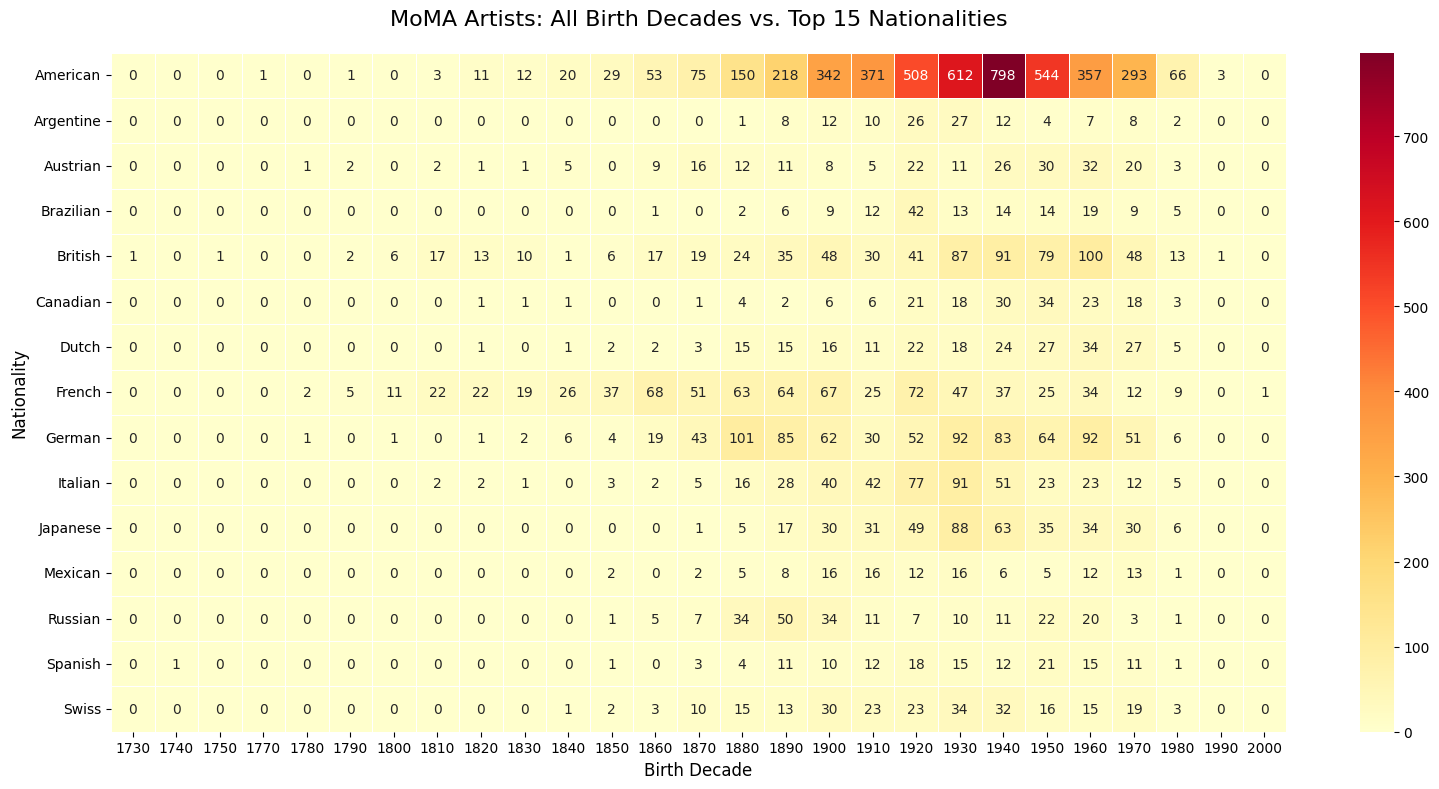

In [7]:

# Get the count of artists (each Decade and each Nationality)
pivot_df = df_top.groupby(['Decade', 'Nationality']).size().unstack(fill_value=0)

# Heatmap
plt.figure(figsize=(16, 8))
# X: Decade; Y: Nationality; Color: Count
sns.heatmap(pivot_df.T, cmap='YlOrRd', linewidths=.5, annot=True, fmt='g')
plt.title('MoMA Artists: All Birth Decades vs. Top 15 Nationalities', fontsize=16, pad=20)
plt.xlabel('Birth Decade', fontsize=12)
plt.ylabel('Nationality', fontsize=12)
plt.tight_layout()
plt.savefig('results/MoMA Artists All Birth Decades vs Top 15 Nationalities.png',
            dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1600x700 with 0 Axes>

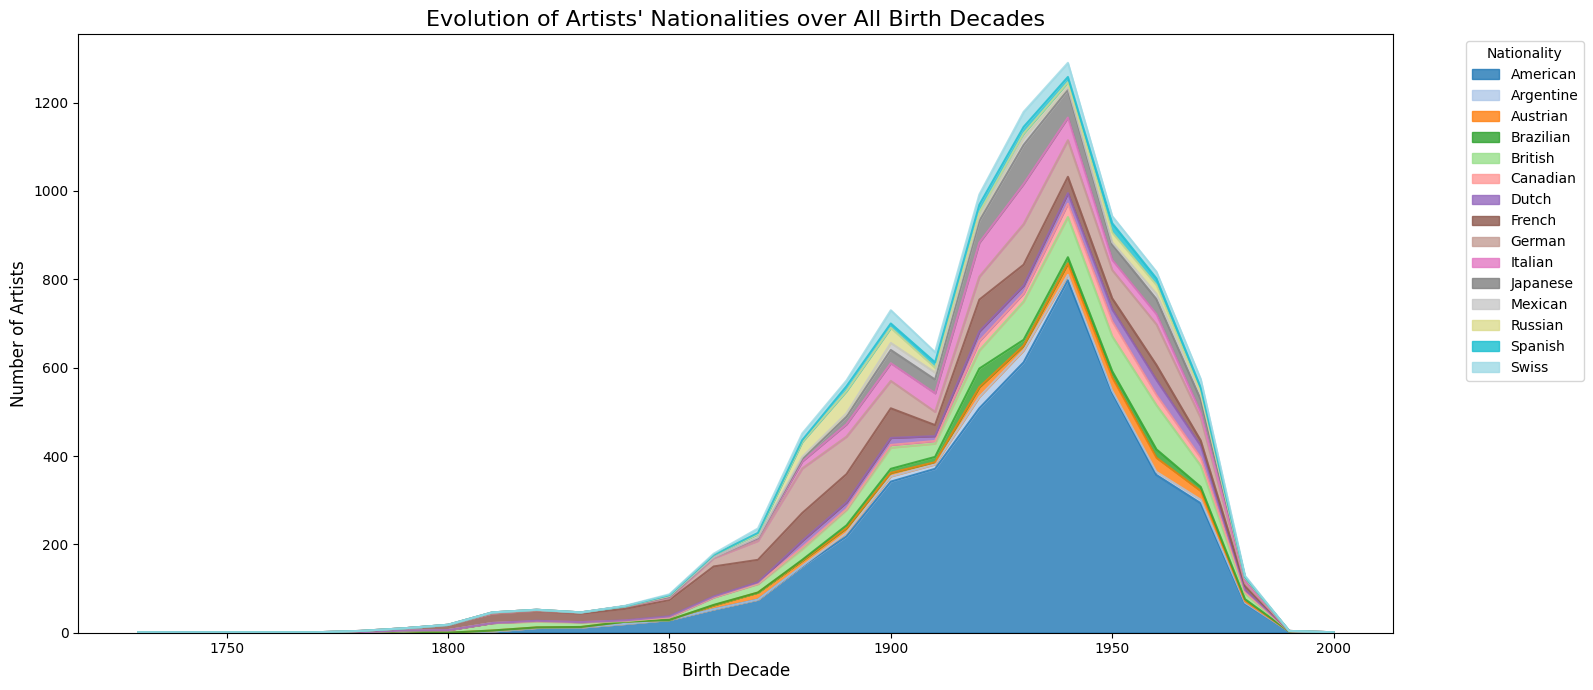

In [8]:
# Same data: an area chart to show the evolution of each nationality(area size — number of artists) 
plt.figure(figsize=(16, 7))
pivot_df.plot(kind='area', stacked=True, colormap='tab20', alpha=0.8, figsize=(16, 7))
plt.title('Evolution of Artists\' Nationalities over All Birth Decades', fontsize=16)
plt.xlabel('Birth Decade', fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.legend(title='Nationality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('results/Evolution of Artists Nationalities over All Birth Decades.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Attempt: To display the distribution of artists from the 1940s on a world map

import plotly.express as px

# Read the cleaned artists data
df = pd.read_csv('../../data/cleaned_artists.csv')

# 1940 <= BeginDate <= 1949
df_1940s = df[(df['BeginDate'] >= 1940) & (df['BeginDate'] <= 1949)].copy()

# Get the count of artists by nationality (1940s)
nat_counts = df_1940s['Nationality'].value_counts().reset_index()
nat_counts.columns = ['Nationality', 'Count']


# Create a mapping(dictionary: nationality -> country name)
nationality_to_country = {
    'American': 'United States',
    'French': 'France',
    'German': 'Germany',
    'British': 'United Kingdom',
    'Japanese': 'Japan',
    'Italian': 'Italy',
    'Swiss': 'Switzerland',
    'Spanish': 'Spain',
    'Russian': 'Russia',
    'Dutch': 'Netherlands',
    'Canadian': 'Canada',
    'Mexican': 'Mexico',
    'Brazilian': 'Brazil',
    'Argentine': 'Argentina',
    'Chilean': 'Chile',
    'Colombian': 'Colombia',
    'Venezuelan': 'Venezuela',
    'Austrian': 'Austria',
    'Belgian': 'Belgium',
    'Danish': 'Denmark',
    'Finnish': 'Finland',
    'Swedish': 'Sweden',
    'Norwegian': 'Norway',
    'Polish': 'Poland',
    'Czech': 'Czech Republic',
    'Hungarian': 'Hungary',
    'Romanian': 'Romania',
    'Greek': 'Greece',
    'Turkish': 'Turkey',
    'Israeli': 'Israel',
    'Indian': 'India',
    'Chinese': 'China',
    'Korean': 'South Korea',
    'Taiwanese': 'Taiwan',
    'Australian': 'Australia',
    'New Zealander': 'New Zealand',
    'South African': 'South Africa',
    'Cuban': 'Cuba',
    'Peruvian': 'Peru',
    'Irish': 'Ireland',
    'Portuguese': 'Portugal',
    'Yugoslav': 'Serbia'
}


nat_counts['Country'] = nat_counts['Nationality'].map(nationality_to_country)

# Check for any unmapped nationalities
unmapped = nat_counts[nat_counts['Country'].isna()]
if not unmapped.empty and unmapped['Count'].max() > 5:
    print("The following nationalities are not mapped and will not be displayed:")
    print(unmapped.head())

# Drop
nat_counts_clean = nat_counts.dropna(subset=['Country'])


# Create Choropleth Map
fig = px.choropleth(
    nat_counts_clean,
    locations="Country",           
    locationmode='country names',
    color="Count",                 
    hover_name="Country",         
    hover_data={"Nationality": True, "Count": True, "Country": False},
    color_continuous_scale=px.colors.sequential.YlOrRd, # yellow-orange-red
    title="Global Distribution of MoMA Artists Born in the 1940s",
)

fig.update_layout(
    geo=dict(
        showframe=False,       
        showcoastlines=True,
        projection_type='natural earth' # also could be:'natural earth'
    ),
    title_x=0.5,
    title_font_size=20
)

fig.write_html('results/Global Distribution of MoMA Artists Born in the 1940s.html')
fig.show()

## 2.2 Analysis2: Artworks Classification of Artist vs. Artworks created time

Goal: To explore the change/evolution of an artist's artworks classification throughout his/her life.

Adjustment: Due to the large number of artists, in order to observe the evolution trend of each artist's own artworks classification, only the top 10 artists in terms of the number of artworks created are selected here.

In [10]:
# Read data
df_art = pd.read_csv('../../data/cleaned_artworks.csv')

df_art['Date'] = pd.to_numeric(df_art['Date'], errors='coerce')
df_art_clean = df_art.dropna(subset=['Date', 'Artist', 'Classification']).copy()

# Top 10 artists by number of artworks
top_10_artists = df_art_clean['Artist'].value_counts().head(10).index
df_top_art = df_art_clean[df_art_clean['Artist'].isin(top_10_artists)]


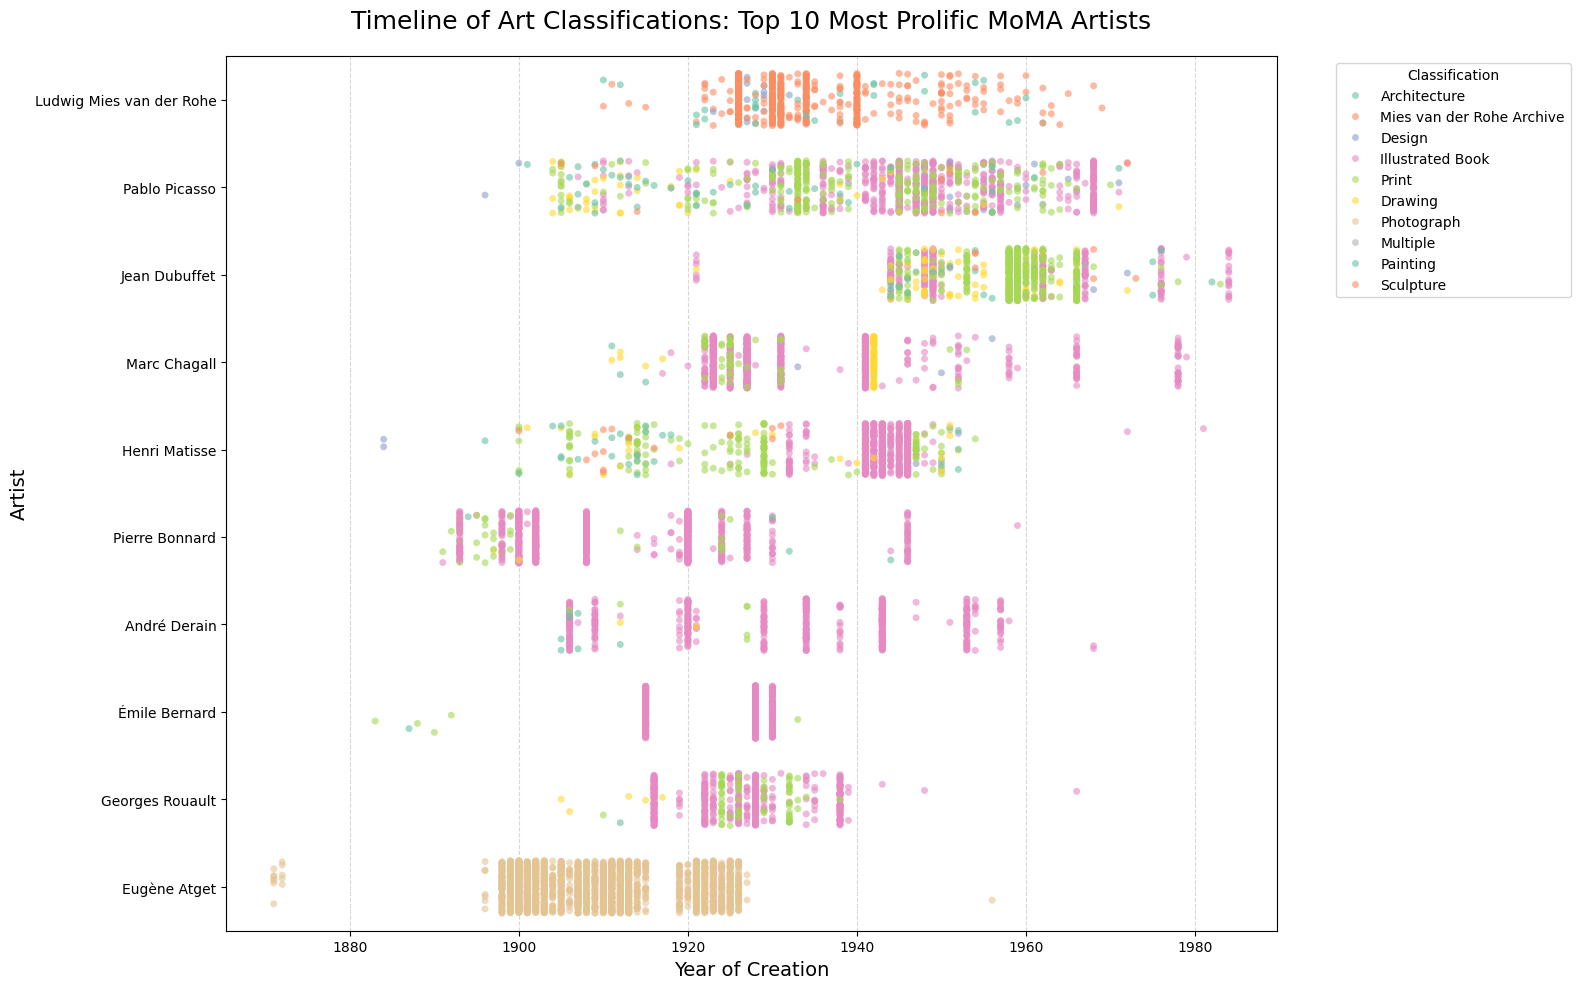

In [ ]:

# Create Strip Plot
plt.figure(figsize=(16, 10))

sns.stripplot(
    data=df_top_art, 
    x='Date', 
    y='Artist', 
    hue='Classification', 
    jitter=0.3, 
    alpha=0.6, 
    size=5, 
    palette='Set2'
)

plt.title('Timeline of Art Classifications: Top 10 Most Prolific MoMA Artists', fontsize=18, pad=20)
plt.xlabel('Year of Creation', fontsize=14)
plt.ylabel('Artist', fontsize=14)

plt.legend(title='Classification', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('results/Timeline of Art Classifications of Top 10 Most Prolific MoMA Artists.png',
            dpi=300, bbox_inches='tight')
plt.show()

## 2.3 Analysis 3: The age of each artist vs artworks they created then

Goal: To Explore the relationship between an artist's creative peak/down and their age.

Adjustment: Due to the large number of artists, only the top 20 artists in terms of the number of artworks created are selected here.

In [12]:
# Read data
df_artworks = pd.read_csv('../../data/cleaned_artworks.csv')
df_artists = pd.read_csv('../../data/cleaned_artists.csv')

# Join two csv files (by ConstituentID)
df_artworks['ConstituentID'] = df_artworks['ConstituentID'].astype(str).str.strip()
df_artists['ConstituentID'] = df_artists['ConstituentID'].astype(str).str.strip()
df_merged = pd.merge(
    df_artworks, 
    df_artists[['ConstituentID', 'BeginDate']], 
    on='ConstituentID', 
    how='left'
)


df_merged['Date'] = pd.to_numeric(df_merged['Date'], errors='coerce')
df_merged['BeginDate'] = pd.to_numeric(df_merged['BeginDate'], errors='coerce')

# Compute the age when each artist created their arts
df_merged['Age_at_Creation'] = df_merged['Date'] - df_merged['BeginDate']

# filter some unreasonable age data
df_valid_age = df_merged[(df_merged['Age_at_Creation'] >= 10) & (df_merged['Age_at_Creation'] <= 110)].copy()


# df_valid_age.to_csv('../../data/cleaned_artworks_with_age.csv', index=False)
# print("Compute the age when each artist created their arts, Save as 'cleaned_artworks_with_age.csv'")

# Top 20 artists by number of artworks
top_20_artists = df_valid_age['Artist'].value_counts().head(20).index
df_top20 = df_valid_age[df_valid_age['Artist'].isin(top_20_artists)]

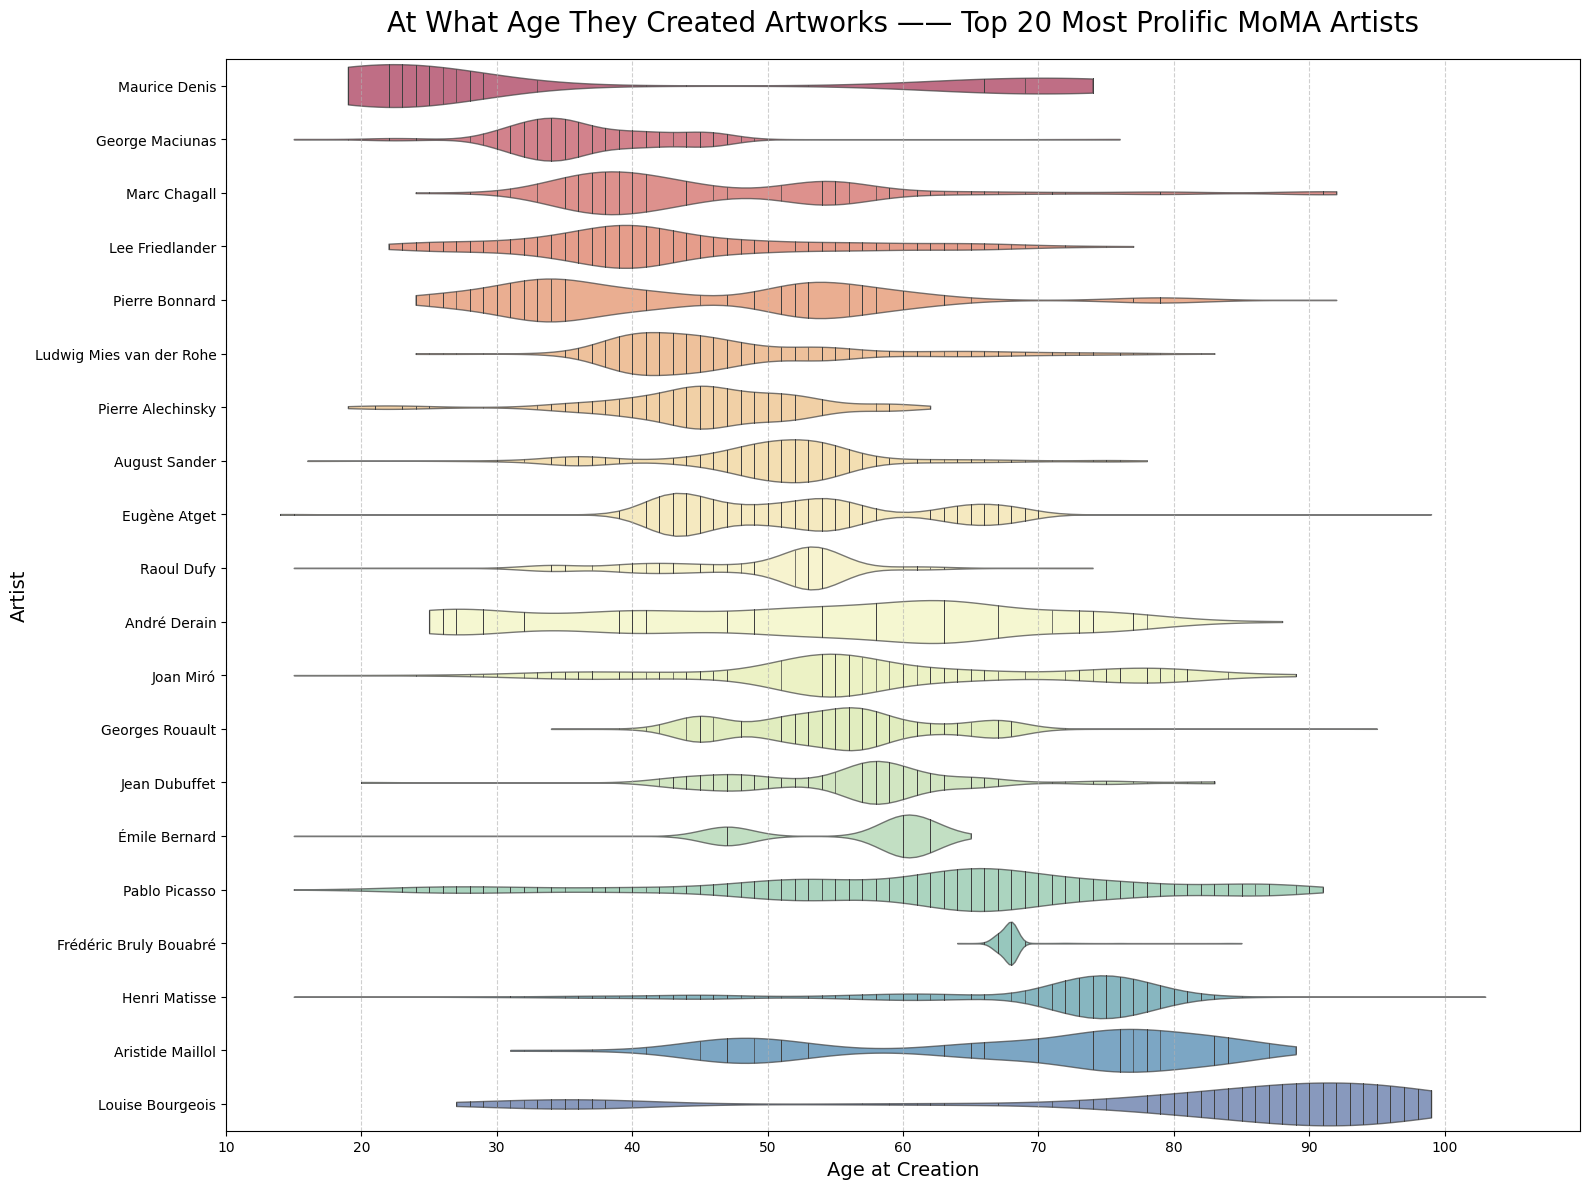

In [ ]:

plt.figure(figsize=(16, 12))
order = df_top20.groupby('Artist')['Age_at_Creation'].median().sort_values().index

# Create Violin Plot
sns.violinplot(
    data=df_top20, 
    x='Age_at_Creation', 
    y='Artist', 
    order=order,
    scale='width',      
    inner='stick',     
    palette='Spectral',
    linewidth=1,
    alpha=0.7,
    cut=0
)
plt.title('At What Age They Created Artworks —— Top 20 Most Prolific MoMA Artists', fontsize=20, pad=20)
plt.xlabel('Age at Creation', fontsize=14)
plt.ylabel('Artist', fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.xticks(range(10, 110, 10))
plt.xlim(10, 110)

plt.tight_layout()
plt.savefig('results/At What Age They Created Artworks of Top 20 Most Prolific MoMA Artists.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Part 3: Data Analysis from Artwork perspective

> **Data source:** We used the already cleaned data file `cleaned_artworks.csv` located under `data/`.

We categorized artworks by creation year and analyzed the following trends over time (year of artwork creation): artwork counts, geographic distribution trends by artist, geographic distribution trends by artwork, gender ratio changes, category proportions across disciplines (using classification and department respectively).

In [21]:
import numpy as np

In [25]:
df = pd.read_csv("../../data/cleaned_artworks.csv")
print(f"Original shape: {df.shape}")
df.head()

Original shape: (87775, 11)


,Title,Artist,ConstituentID,Nationality,Gender,Date,Classification,Department,ObjectID,URL,ThumbnailURL
0,"Ferdinandsbrücke Project, Vienna, Austria (Ele...",Otto Wagner,6210,Austrian,Male,1896,Architecture,Architecture & Design,2,http://www.moma.org/collection/works/2,http://www.moma.org/media/W1siZiIsIjU5NDA1Il0s...
1,"City of Music, National Superior Conservatory ...",Christian de Portzamparc,7470,French,Male,1987,Architecture,Architecture & Design,3,http://www.moma.org/collection/works/3,http://www.moma.org/media/W1siZiIsIjk3Il0sWyJw...
2,"Villa near Vienna Project, Outside Vienna, Aus...",Emil Hoppe,7605,Austrian,Male,1903,Architecture,Architecture & Design,4,http://www.moma.org/collection/works/4,http://www.moma.org/media/W1siZiIsIjk4Il0sWyJw...
3,"Villa, project, outside Vienna, Austria, Exter...",Emil Hoppe,7605,Austrian,Male,1903,Architecture,Architecture & Design,6,http://www.moma.org/collection/works/6,http://www.moma.org/media/W1siZiIsIjEyNiJdLFsi...
4,"Memorial to the Six Million Jewish Martyrs, pr...",Louis I. Kahn,2964,American,Male,1968,Architecture,Architecture & Design,32,http://www.moma.org/collection/works/32,http://www.moma.org/media/W1siZiIsIjE3MyJdLFsi...


In [28]:
# Create decade
df['Decade'] = (df['Date'] // 10) * 10

# Remove duplicates by ObjectID to count each artwork only once
unique_artworks = df.drop_duplicates(subset='ObjectID')
unique_artworks.head()

,Title,Artist,ConstituentID,Nationality,Gender,Date,Classification,Department,ObjectID,URL,ThumbnailURL,Decade
0,"Ferdinandsbrücke Project, Vienna, Austria (Ele...",Otto Wagner,6210,Austrian,Male,1896,Architecture,Architecture & Design,2,http://www.moma.org/collection/works/2,http://www.moma.org/media/W1siZiIsIjU5NDA1Il0s...,1890
1,"City of Music, National Superior Conservatory ...",Christian de Portzamparc,7470,French,Male,1987,Architecture,Architecture & Design,3,http://www.moma.org/collection/works/3,http://www.moma.org/media/W1siZiIsIjk3Il0sWyJw...,1980
2,"Villa near Vienna Project, Outside Vienna, Aus...",Emil Hoppe,7605,Austrian,Male,1903,Architecture,Architecture & Design,4,http://www.moma.org/collection/works/4,http://www.moma.org/media/W1siZiIsIjk4Il0sWyJw...,1900
3,"Villa, project, outside Vienna, Austria, Exter...",Emil Hoppe,7605,Austrian,Male,1903,Architecture,Architecture & Design,6,http://www.moma.org/collection/works/6,http://www.moma.org/media/W1siZiIsIjEyNiJdLFsi...,1900
4,"Memorial to the Six Million Jewish Martyrs, pr...",Louis I. Kahn,2964,American,Male,1968,Architecture,Architecture & Design,32,http://www.moma.org/collection/works/32,http://www.moma.org/media/W1siZiIsIjE3MyJdLFsi...,1960


## 3.1 Annual Artwork Creation Trends

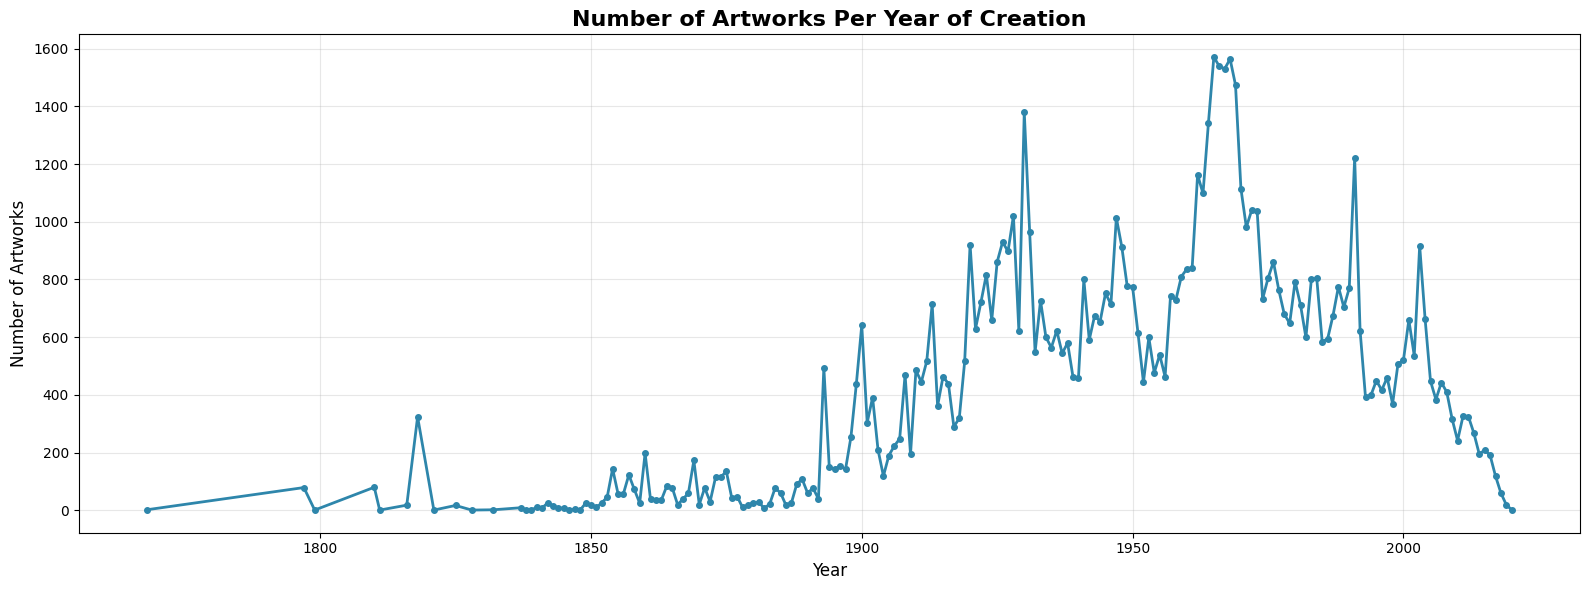

In [ ]:
# Count artworks by year
yearly_counts = unique_artworks.groupby('Date').size().reset_index(name='Count')
yearly_counts = yearly_counts.sort_values('Date')

# Create single line chart
plt.figure(figsize=(16, 6))
plt.plot(yearly_counts['Date'], yearly_counts['Count'], 
         color='#2E86AB', linewidth=2, marker='o', markersize=4)

plt.title('Number of Artworks Per Year of Creation', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Artworks', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('results/Number of Artworks Per Year of Creation.png',
            dpi=300, bbox_inches='tight')

plt.show()

## 3.2 Geographic Distribution of Artworks Over Time

Note: some artworks are created by multiple artists. In such cases, we allocate shares proportionally. For example, if a piece is co-created by three Americans, one Japanese and one Indian, the count would be recorded as 0.6 for the U.S., 0.2 for Japan, and 0.2 for India. As a result, the final totals may include decimals.

<Figure size 1600x800 with 0 Axes>

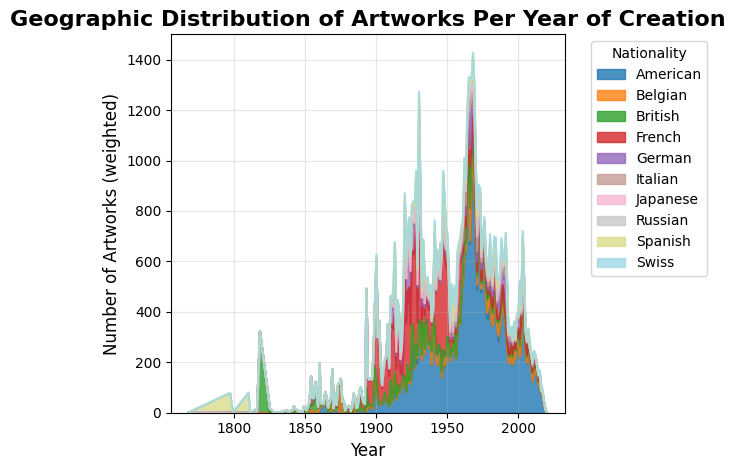


Top 50 Nationalities by Artwork Count (weighted):
Nationality
American         34718.985729
French           17372.442459
German            6294.640815
British           4422.402169
Spanish           2566.005780
Italian           1920.361680
Japanese          1586.354893
Russian           1565.307143
Swiss             1309.370810
Belgian           1070.181668
Mexican            984.515098
Dutch              922.638946
Canadian           673.419273
Austrian           666.042913
Czech              527.037233
Brazilian          506.306308
Colombian          482.421182
Ivorian            481.000000
Argentine          449.322934
Chilean            393.795635
Polish             341.458547
Danish             331.769045
South African      267.540909
Israeli            233.550000
Venezuelan         220.441379
Australian         193.598214
Chinese            187.583333
Swedish            173.087652
Finnish            129.000000
Hungarian          118.511204
Cuban              118.225433
Yugosla

In [ ]:
# Calculate the weight for each artist based on the number of artists for the artwork
df['Weight'] = df.groupby('ObjectID')['ObjectID'].transform('count')  # number of artists per artwork
df['Weight'] = 1 / df['Weight']  # each artist contributes 1 / num_artists

# Now group by Nationality and Date using the weighted count
geo_time_dist = df.groupby(['Nationality', 'Date'])['Weight'].sum().reset_index(name='Count')

# Get top 10 nationalities
top_nats = df.groupby('Nationality')['Weight'].sum().sort_values(ascending=False).head(10).index.tolist()
df_top_nats = geo_time_dist[geo_time_dist['Nationality'].isin(top_nats)]

# Create pivot table and plot
pivot_data = df_top_nats.pivot_table(index='Date', columns='Nationality', values='Count', fill_value=0)

plt.figure(figsize=(16, 8))
pivot_data.plot.area(stacked=True, alpha=0.8, colormap='tab20')
plt.title('Geographic Distribution of Artworks Per Year of Creation', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Artworks (weighted)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Nationality')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/Geographic Distribution of Artworks Per Year of Creation.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Print top 50 nationalities by weighted artwork count
print("\nTop 50 Nationalities by Artwork Count (weighted):")
print(df.groupby('Nationality')['Weight'].sum().sort_values(ascending=False).head(50))

## 3.3 Geographic Distribution of Artists Over Time (based on the year of artwork creation)

Note: Regardless of the number of shared or individual works, each artist's nationality is counted only once per year if they were active.

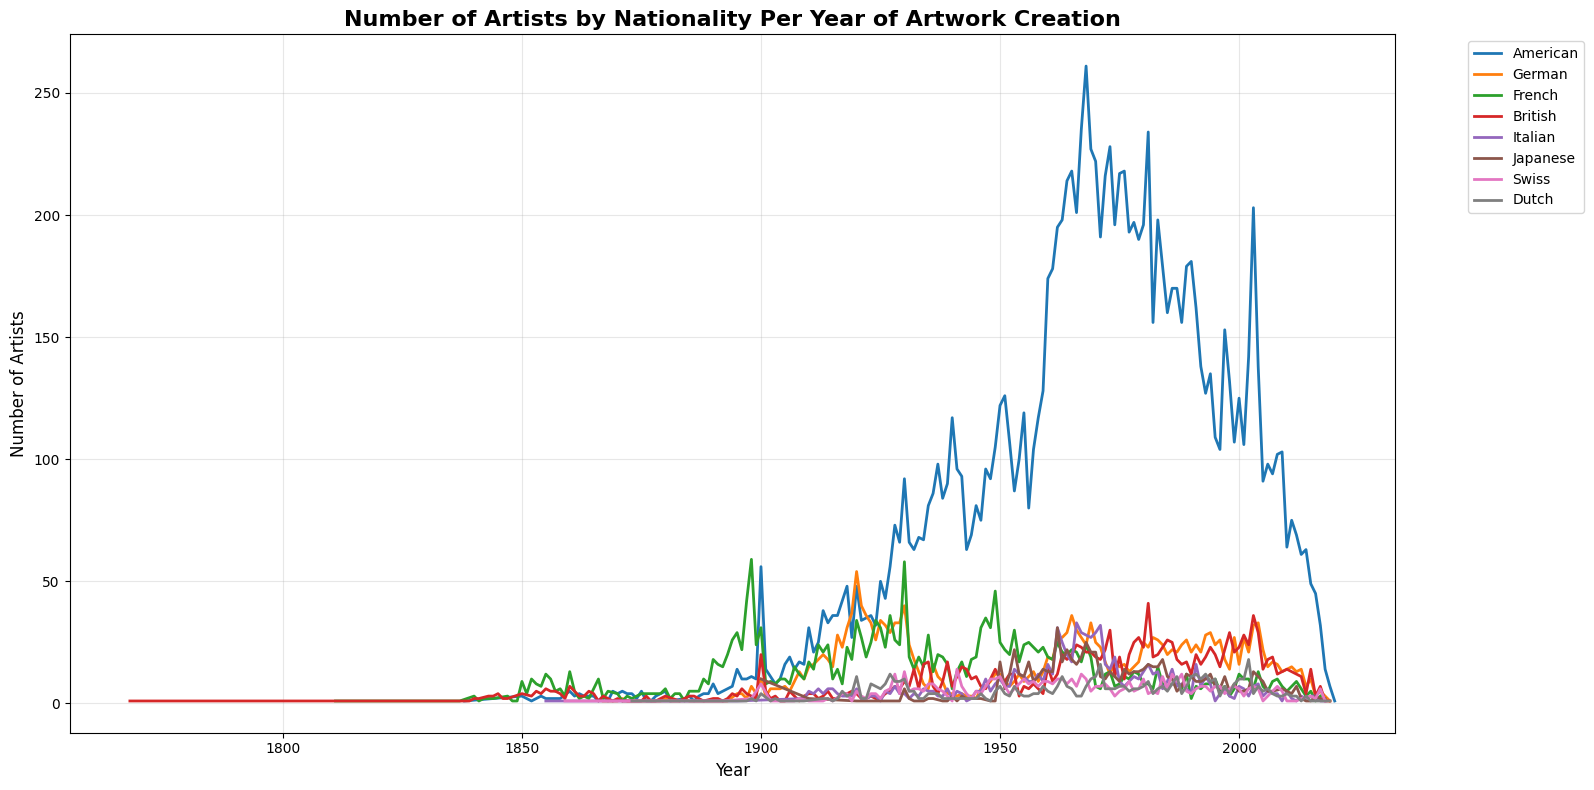

In [ ]:
# Remove duplicates: each artist counts only once per year per nationality
df_unique_artists = df[['Date', 'Nationality', 'Artist']].drop_duplicates()

# Count unique artists by nationality and year
artist_geo = df_unique_artists.groupby(['Date', 'Nationality'])['Artist'].nunique().reset_index(name='Artist_Count')

# Get top 10 nationalities by artist count
top_artist_nats = df_unique_artists.groupby('Nationality')['Artist'].nunique().sort_values(ascending=False).head(10).index.tolist()
df_top_artists = artist_geo[artist_geo['Nationality'].isin(top_artist_nats)]

# Create pivot table and plot
pivot_artists = df_top_artists.pivot_table(index='Date', columns='Nationality', values='Artist_Count', fill_value=0)

plt.figure(figsize=(16, 8))
for nationality in top_artist_nats[:8]:
    data = df_top_artists[df_top_artists['Nationality'] == nationality]
    plt.plot(data['Date'], data['Artist_Count'], label=nationality, linewidth=2)

plt.title('Number of Artists by Nationality Per Year of Artwork Creation', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/Number of Artists by Nationality Per Year of Artwork Creation.png',
            dpi=300, bbox_inches='tight')
plt.show()

We print the top 10 countries with most active artists in 1900, 1950 and 2000 respectively.

In [32]:
# Years of interest
years = [1900, 1950, 2000]

for year in years:
    df_year = df_unique_artists[df_unique_artists['Date'] == year]
    
    # Count unique artists per nationality
    top_nationalities = df_year.groupby('Nationality')['Artist'].nunique().sort_values(ascending=False).head(10)
    
    print(f"\nTop 10 nationalities by artist count in {year}:")
    print(top_nationalities.to_string(header=False))


Top 10 nationalities by artist count in 1900:
American     56
French       31
British      20
German       10
Japanese     10
Swiss         8
Austrian      4
Dutch         4
Argentine     1
Belgian       1

Top 10 nationalities by artist count in 1950:
American     122
French        25
Japanese      17
German        12
Swiss         11
British       10
Italian       10
Danish         8
Dutch          7
Brazilian      5

Top 10 nationalities by artist count in 2000:
American         125
British           23
South African     16
German            16
Austrian          14
French            12
Dutch             10
Chinese            8
Canadian           7
Italian            7


## 3.4 Gender Distribution of Artworks Over Time

Note: similarly with part 3.2, some artworks are created by multiple artists. In such cases, we allocate shares proportionally. For example, if a piece is co-created by 3 men and 2 women, the count would be recorded as 0.6 for men and 0.4 for women. As a result, the final totals may include decimals.

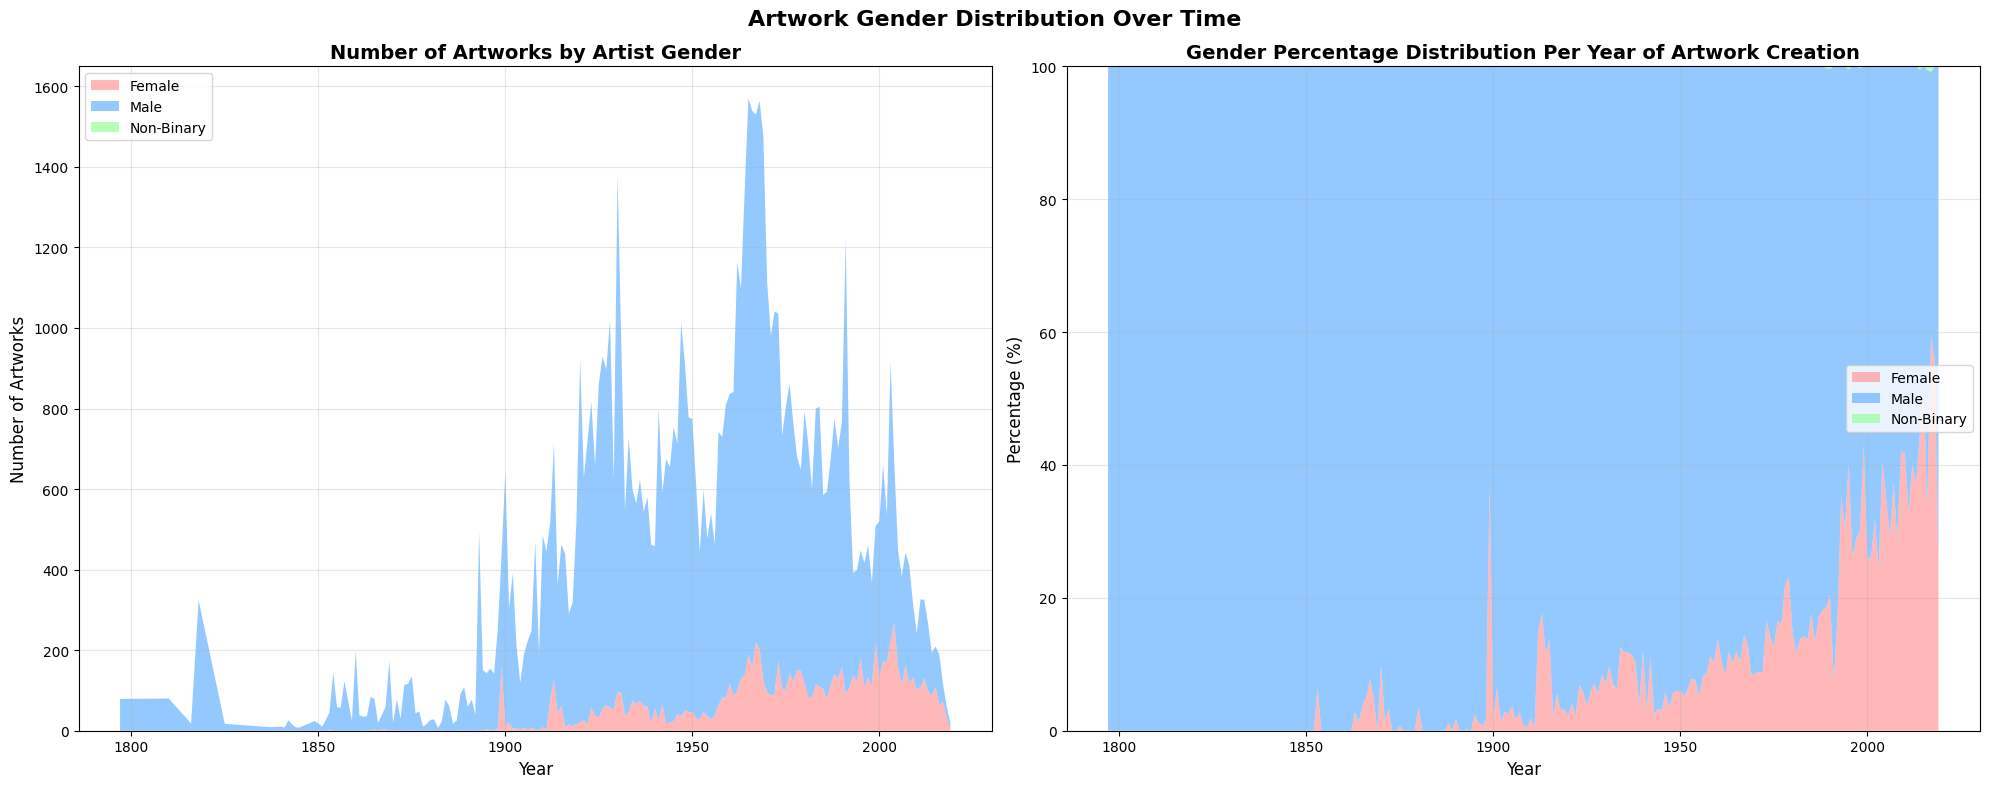


GENDER DISTRIBUTION SUMMARY (Weighted by multi-artist contributions)
Male: 72540.81 (87.72%)
Female: 10141.99 (12.26%)
Non-Binary: 11.20 (0.01%)


In [ ]:
# Include all gender categories (Female, Male, Non-Binary)
df_gender = df[df['Gender'].notna()].copy()  # Keep all non-null genders

df_gender['Weight'] = 1 / df_gender.groupby('ObjectID')['ObjectID'].transform('count')
gender_by_year = df_gender.groupby(['Date', 'Gender'])['Weight'].sum().reset_index(name='Count')
gender_pivot = gender_by_year.pivot_table(index='Date', columns='Gender', values='Count', fill_value=0)
gender_categories = gender_pivot.columns.tolist()
colors = {'Female': '#ff9999', 'Male': '#66b3ff', 'Non-Binary': '#99ff99'}

# Calculate total artworks per year (for filtering and percentages)
gender_pivot['Total'] = gender_pivot.sum(axis=1)
gender_filtered = gender_pivot[gender_pivot['Total'] >= 5].copy()

# Calculate percentages for each gender
for gender in gender_categories:
    gender_filtered[f'{gender}_Pct'] = (gender_filtered[gender] / gender_filtered['Total']) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot stacked area chart (absolute numbers)
ax1.stackplot(gender_filtered.index, 
              *[gender_filtered[gender] for gender in gender_categories],
              labels=gender_categories,
              colors=[colors.get(g, '#cccccc') for g in gender_categories],
              alpha=0.7)
ax1.set_title('Number of Artworks by Artist Gender', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Artworks', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot percentage over time (stacked area)
ax2.stackplot(gender_filtered.index, 
              *[gender_filtered[f'{gender}_Pct'] for gender in gender_categories],
              labels=gender_categories,
              colors=[colors.get(g, '#cccccc') for g in gender_categories],
              alpha=0.7)
ax2.set_title('Gender Percentage Distribution Per Year of Artwork Creation', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_ylim(0, 100)
ax2.legend(loc='center right')
ax2.grid(True, alpha=0.3)

plt.suptitle('Artwork Gender Distribution Over Time', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results/Artwork Gender Distribution Per Year of Artwork Creation.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Print weighted summary statistics
print("\n" + "="*60)
print("GENDER DISTRIBUTION SUMMARY (Weighted by multi-artist contributions)")
print("="*60)

total_gender_weighted = df_gender.groupby('Gender')['Weight'].sum().sort_values(ascending=False)
for gender, w in total_gender_weighted.items():
    percentage = (w / total_gender_weighted.sum()) * 100
    print(f"{gender}: {w:.2f} ({percentage:.2f}%)")

## 3.5 Classification Percentage Changes Over Time

Total unique classifications: 32
Top 10 classifications:
Classification
Illustrated Book    22962
Print               18445
Photograph          16473
Drawing              7910
Design               6948
Video                1893
Painting             1822
Sculpture            1268
Architecture          998
Multiple              759
Name: count, dtype: int64

Decades with data:
[1790, 1810, 1820, 1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010]


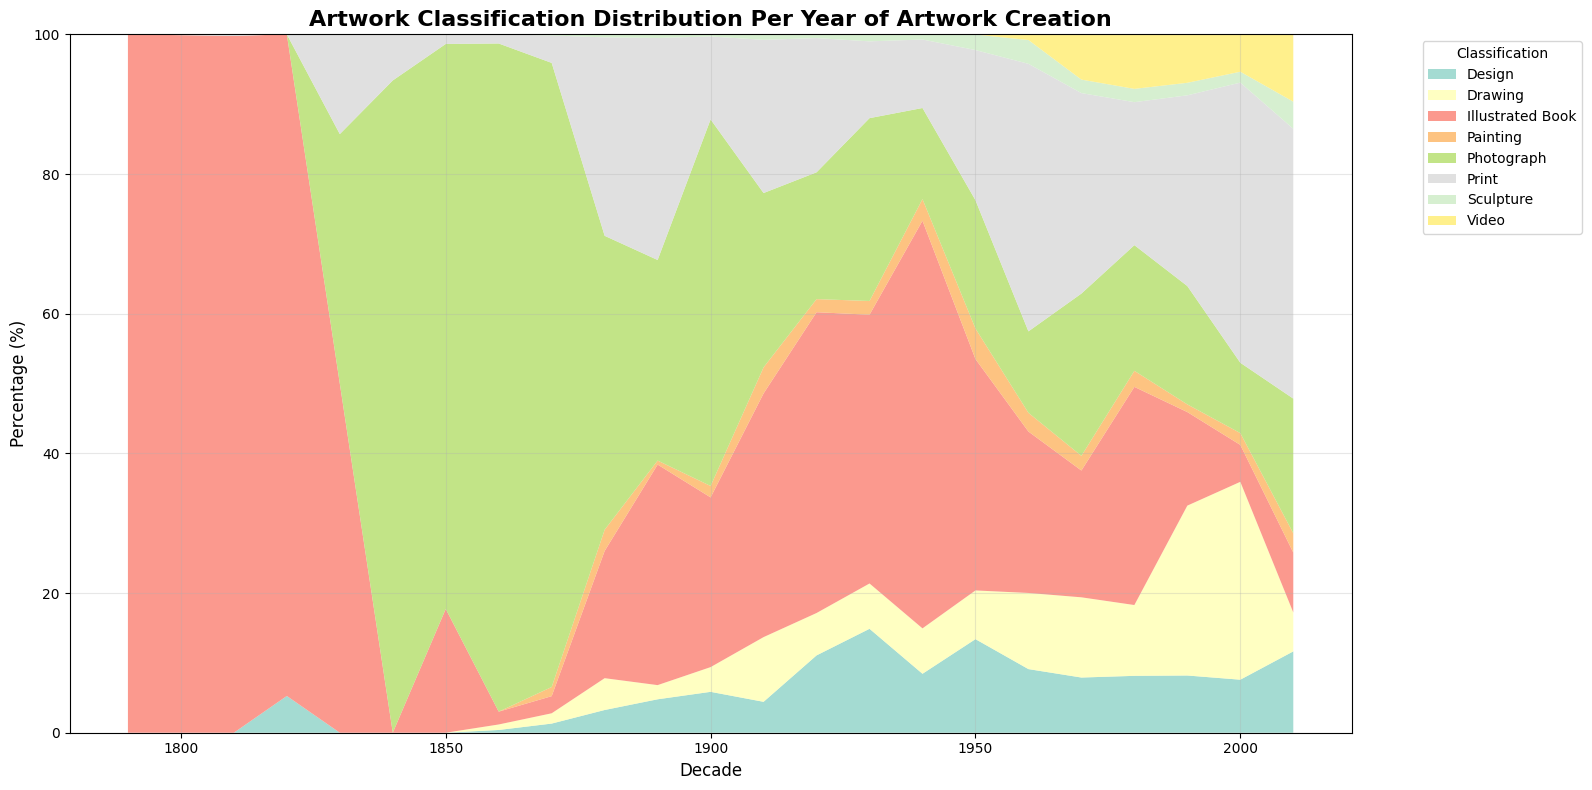


Artwork Classification Distribution by Decade (%):
Classification  Design  Drawing  Illustrated Book  Painting  Photograph  \
Decade                                                                    
1790              0.00     0.00            100.00      0.00        0.00   
1810              0.00     0.00             99.76      0.00        0.00   
1820              5.26     0.00             94.74      0.00        0.00   
1830              0.00     0.00             50.00      0.00       35.71   
1840              0.00     0.00              0.00      0.00       93.40   
1850              0.00     0.00             17.73      0.00       80.90   
1860              0.39     0.79              1.84      0.00       95.67   
1870              1.31     1.47              2.45      1.31       89.36   
1880              3.25     4.56             18.22      3.04       42.08   
1890              4.79     2.03             31.58      0.57       28.72   
1900              5.85     3.54             24.3

In [ ]:
# Get all classifications
all_classes = unique_artworks['Classification'].value_counts().index.tolist()
print(f"Total unique classifications: {len(all_classes)}")
print("Top 10 classifications:")
print(unique_artworks['Classification'].value_counts().head(10))

# Use top 8 classifications for visualization
top_classes = unique_artworks['Classification'].value_counts().head(8).index.tolist()
df_class = unique_artworks[unique_artworks['Classification'].isin(top_classes)]

# Calculate percentage distribution by decade
class_by_decade = pd.crosstab(
    df_class['Decade'],
    df_class['Classification'],
    normalize='index'
) * 100

# Filter decades with sufficient data
decade_counts = unique_artworks.groupby('Decade').size()
valid_decades = decade_counts[decade_counts >= 5].index
class_by_decade = class_by_decade[class_by_decade.index.isin(valid_decades)]

print("\nDecades with data:")
print(class_by_decade.index.tolist())

# Plot stacked area chart
plt.figure(figsize=(16, 8))

colors = plt.cm.Set3(np.linspace(0, 1, len(class_by_decade.columns)))

plt.stackplot(
    class_by_decade.index,
    class_by_decade.values.T,
    labels=class_by_decade.columns.tolist(),
    colors=colors,
    alpha=0.8
)

plt.title('Artwork Classification Distribution Per Year of Artwork Creation', fontsize=16, fontweight='bold')
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.ylim(0, 100)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Classification')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    'results/Artwork Classification Distribution Per Year of Artwork Creation.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Display percentage distribution by decade
print("\nArtwork Classification Distribution by Decade (%):")
print(class_by_decade.round(2))

## 3.6 Analysis by Department (Collection Areas)


Total unique departments: 8
Department value counts:
Department
Drawings & Prints                        51040
Photography                              16170
Architecture & Design                     8939
Painting & Sculpture                      3000
Media and Performance                     2117
Film                                       971
Fluxus Collection                          449
Architecture & Design - Image Archive        8
Name: count, dtype: int64


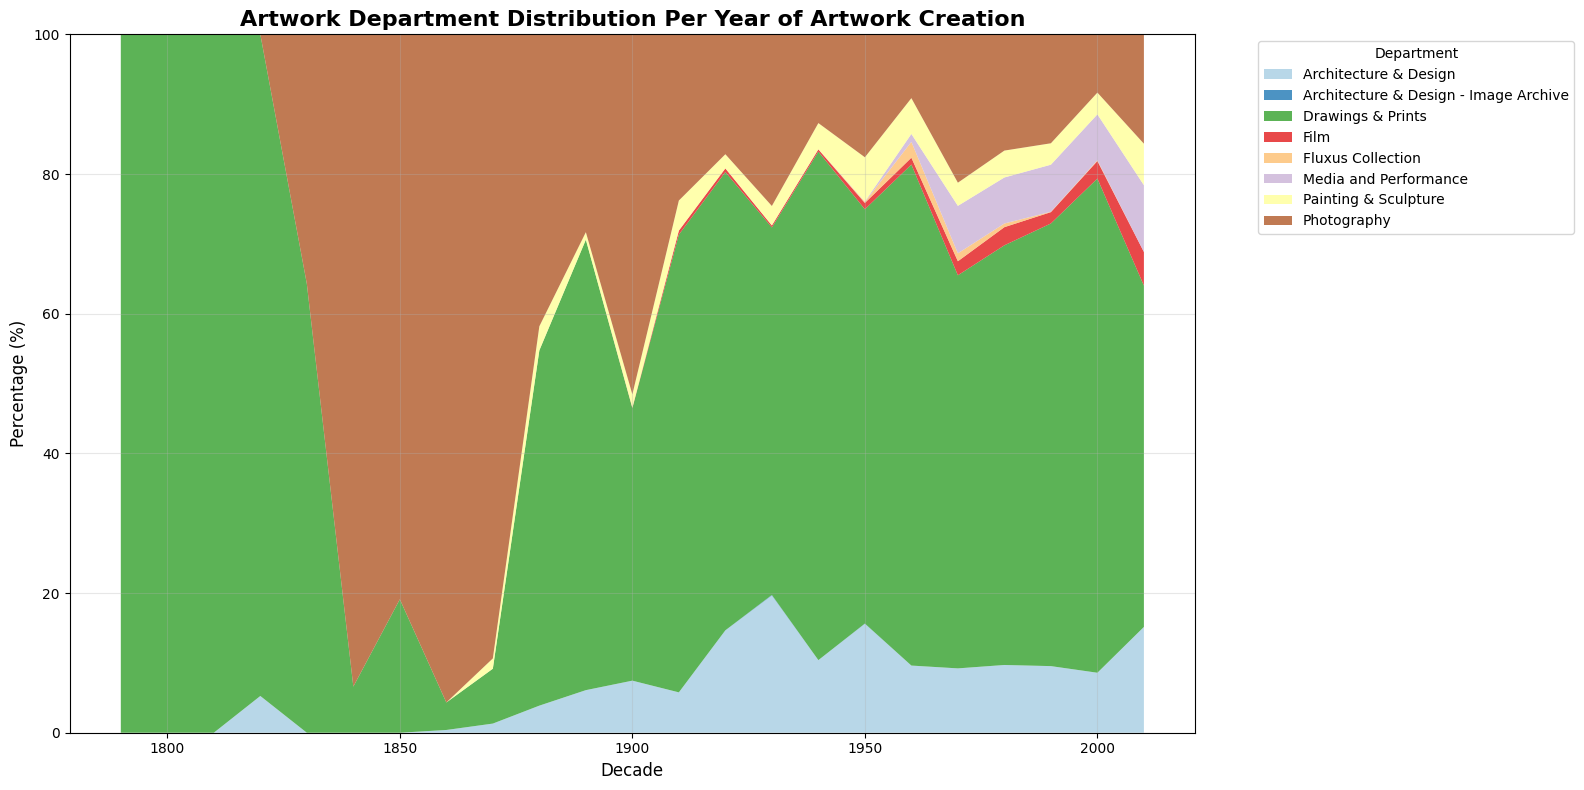


Artwork Department Distribution by Decade (%):
Department  Architecture & Design  Architecture & Design - Image Archive  \
Decade                                                                     
1790                         0.00                                   0.00   
1810                         0.00                                   0.00   
1820                         5.26                                   0.00   
1830                         0.00                                   0.00   
1840                         0.00                                   0.00   
1850                         0.00                                   0.00   
1860                         0.39                                   0.00   
1870                         1.31                                   0.00   
1880                         3.88                                   0.00   
1890                         6.10                                   0.00   
1900                         7.46       

In [ ]:
# Use unique artworks to avoid counting the same artwork multiple times
df_dept = unique_artworks.copy()

# Get all departments
all_depts = df_dept['Department'].value_counts().index.tolist()
print(f"\nTotal unique departments: {len(all_depts)}")
print("Department value counts:")
print(df_dept['Department'].value_counts())

# Select top 8 most frequent departments
top_depts = df_dept['Department'].value_counts().head(8).index.tolist()
df_dept = df_dept[df_dept['Department'].isin(top_depts)]

# Calculate percentage distribution by decade
dept_by_decade = pd.crosstab(
    df_dept['Decade'],
    df_dept['Department'],
    normalize='index'
) * 100

# Filter decades with sufficient data
dept_by_decade = dept_by_decade[dept_by_decade.index.isin(valid_decades)]

# Create stacked area chart
plt.figure(figsize=(16, 8))
colors = plt.cm.Paired(np.linspace(0, 1, len(dept_by_decade.columns)))

plt.stackplot(
    dept_by_decade.index,
    dept_by_decade.values.T,
    labels=dept_by_decade.columns.tolist(),
    colors=colors,
    alpha=0.8
)

plt.title('Artwork Department Distribution Per Year of Artwork Creation', fontsize=16, fontweight='bold')
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.ylim(0, 100)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Department')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    'results/Artwork Department Distribution Per Year of Artwork Creation.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# Display percentage distribution by decade
print("\nArtwork Department Distribution by Decade (%):")
print(dept_by_decade.round(2))